## Name: Hanouf Almogri

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

### 1. Explain the difference between a figure and an axes in matplotlib. (1-2 sentences)

figure is the overall canvas or whole window that holds everything, while an axes is the individual plot area inside the figure where data is actually drawn. One figure can contain one or multiple axes.


### 2. Name the three figure-level functions in seaborn.

relplot()
displot()
catplot()

### 3. Briefly explain the difference between a Histogram and a Barplot. Which one is used to show the distribution of numerical data, and which is used for categorical data?

histogram shows how numerical values are distributed by grouping them into intervals called bins. A barplot compares values across categories, where each bar represents a category.

We use se a histogram for the distribution of numerical data, and use a barplot for categorical data.


## B. Subplots and Grids

### 1. Using a seaborn figure-level function (like sns.relplot or sns.displot), create subplots using the col and row parameters. For example, plot flipper_length_mm vs body_mass_g across columns for sex and rows for island.

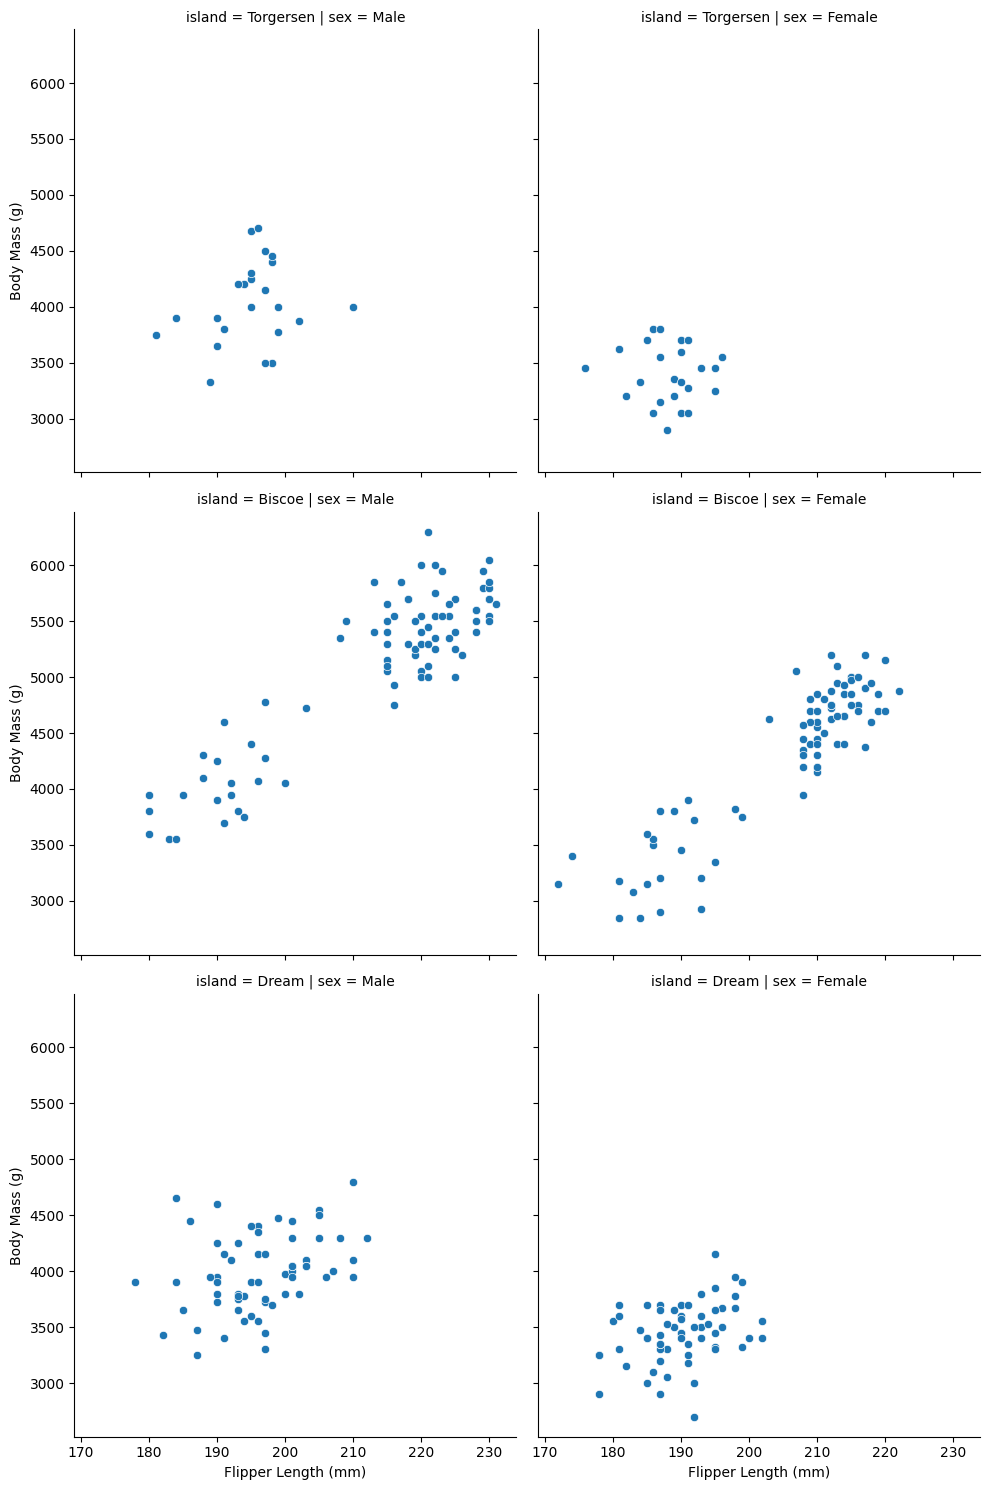

In [2]:
g = sns.relplot(
    data=df.dropna(subset=['flipper_length_mm', 'body_mass_g', 'sex', 'island']),
    x='flipper_length_mm',
    y='body_mass_g',
    col='sex',
    row='island',
    kind='scatter'
)

g.set_axis_labels("Flipper Length (mm)", "Body Mass (g)")
plt.show()

### 2. Using axes-level functions, create a figure with subplots (e.g., 1 row and 2 columns) using plt.subplots. - Plot a scatterplot of bill_length_mm vs bill_depth_mm on the first axes (ax1). - Plot a boxplot (or another axes-level plot of your choice) of bill_length_mm by species on the second axes (ax2). - Make sure to use sharey=True (or sharex=True) where appropriate so the subplots are linked on the shared dimension.

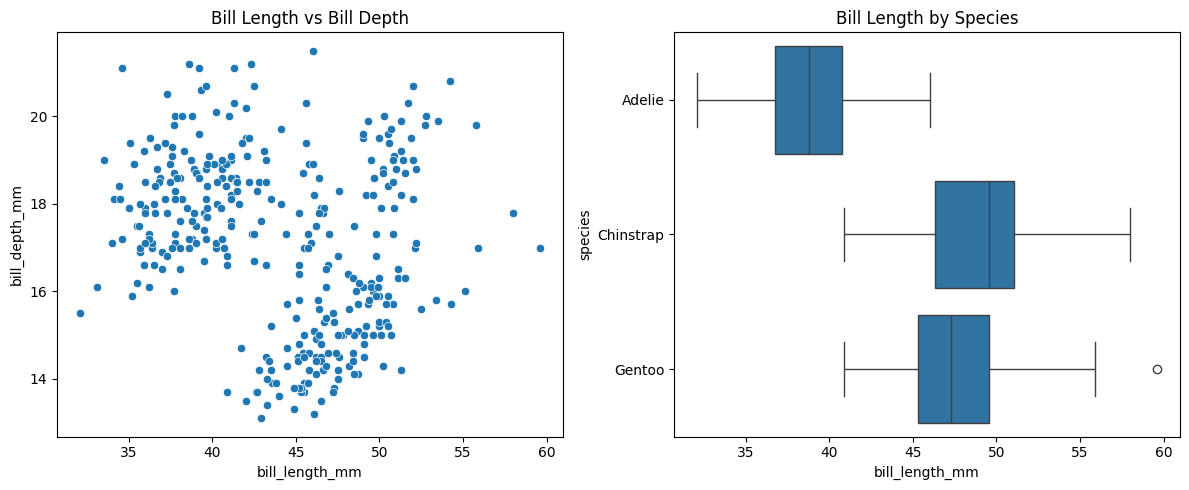

In [5]:
df2 = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

sns.scatterplot(
    data=df2,
    x='bill_length_mm',
    y='bill_depth_mm',
    ax=ax1
)
ax1.set_title('Bill Length vs Bill Depth')

sns.boxplot(
    data=df2,
    x='bill_length_mm',
    y='species',
    ax=ax2
)
ax2.set_title('Bill Length by Species')

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

### 1. Write code to show a box plot of flipper_length_mm separated by species.

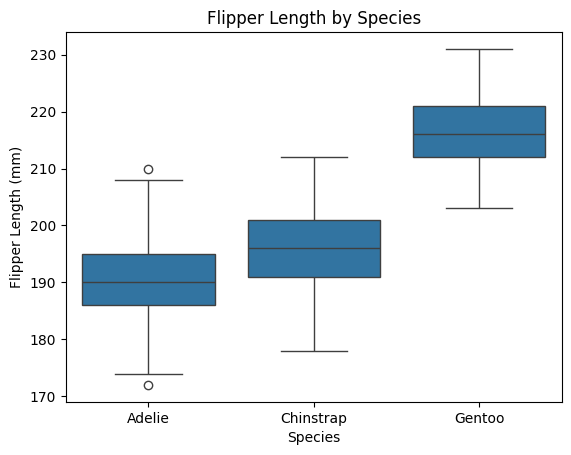

In [6]:
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.title("Flipper Length by Species")
plt.show()

### 2. Show two distributions on the same figure axes: plot the distribution of body_mass_g grouped by sex (e.g., using sns.kdeplot, or sns.histplot with overlapping transparent bins).

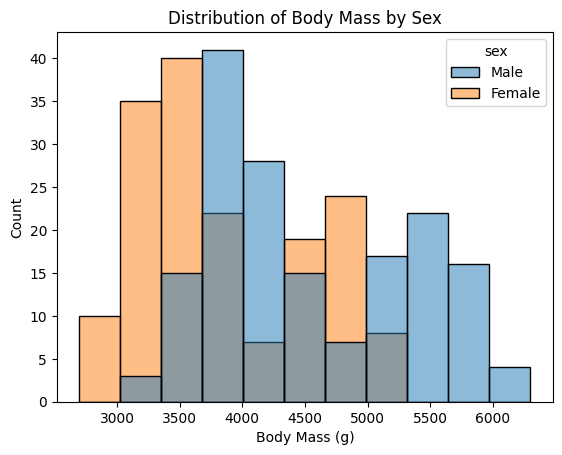

In [7]:
df3 = df.dropna(subset=['body_mass_g', 'sex'])

sns.histplot(
    data=df3,
    x='body_mass_g',
    hue='sex',
    multiple='layer',
    alpha=0.5
)

plt.xlabel("Body Mass (g)")
plt.ylabel("Count")
plt.title("Distribution of Body Mass by Sex")
plt.show()

### 3. Plot the Empirical Cumulative Distribution Function (ECDF) for body_mass_g, split by species. Briefly interpret what the plot tells you about how the species compare in weight.

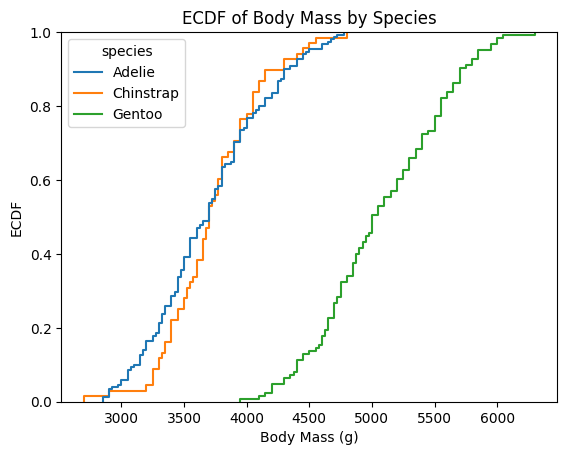

In [8]:
df4 = df.dropna(subset=['body_mass_g', 'species'])

sns.ecdfplot(data=df4, x='body_mass_g', hue='species')
plt.xlabel("Body Mass (g)")
plt.ylabel("ECDF")
plt.title("ECDF of Body Mass by Species")
plt.show()

### 4. Plot a bi-variate histogram using sns.histplot showing bill_length_mm on the x-axis and bill_depth_mm on the y-axis. What does the intensity mapping (the color blocks) represent?

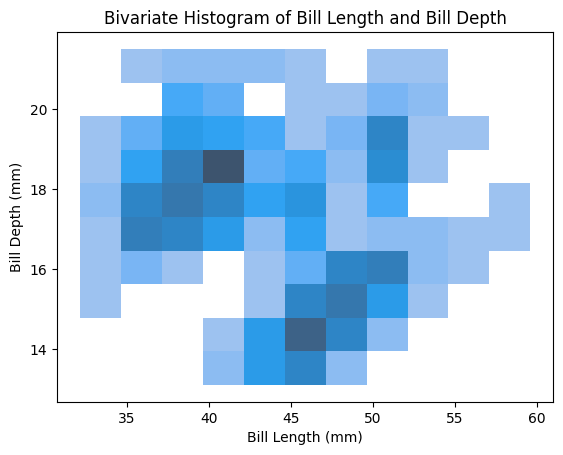

In [10]:
df5 = df.dropna(subset=['bill_length_mm', 'bill_depth_mm'])

sns.histplot(
    data=df5,
    x='bill_length_mm',
    y='bill_depth_mm'
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.title("Bivariate Histogram of Bill Length and Bill Depth")
plt.show()

## D. Categorical Data

### 1. Visualize numerical vs categorical relationships using sns.catplot(). Plot bill_depth_mm across different islands. Experiment with different categorical plot kinds (e.g., kind='violin' or kind='swarm').

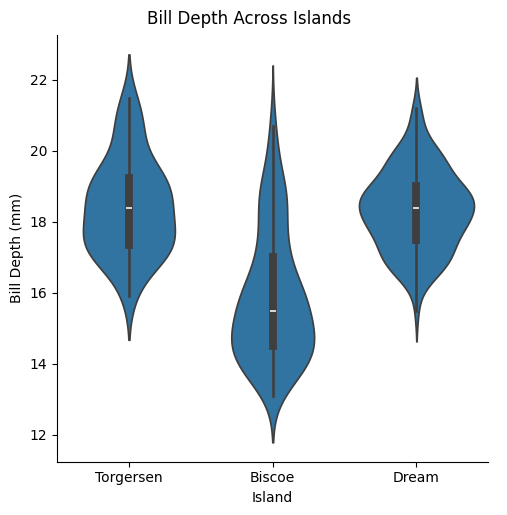

In [ ]:
df6 = df.dropna(subset=['bill_depth_mm', 'island'])
#using violin
g = sns.catplot(
    data=df6,
    x='island',
    y='bill_depth_mm',
    kind='violin'
)

g.set_axis_labels("Island", "Bill Depth (mm)")
g.fig.suptitle("Bill Depth Across Islands", y=1.02)
plt.show()

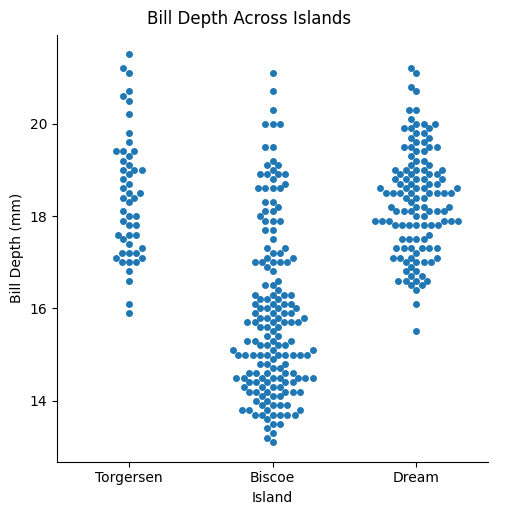

In [12]:
#using swarm
g = sns.catplot(
    data=df6,
    x='island',
    y='bill_depth_mm',
    kind='swarm'
)

g.set_axis_labels("Island", "Bill Depth (mm)")
g.fig.suptitle("Bill Depth Across Islands", y=1.02)
plt.show()


### 2. Visualize multiple categorical variables in one plot. Show a count of penguins by island, and further separate the counts by species (using the hue parameter in a count plot or a similar approach).

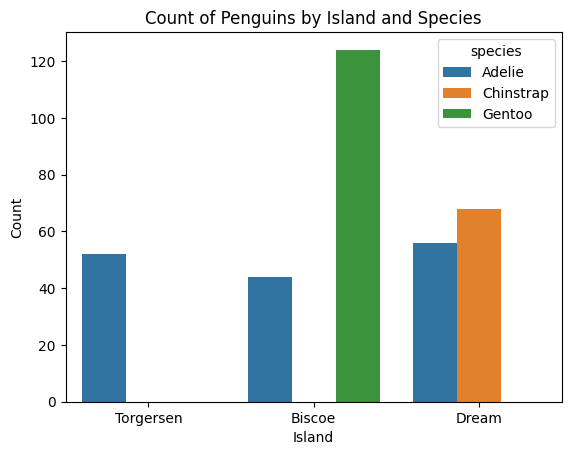

In [13]:

df7 = df.dropna(subset=['island', 'species'])

sns.countplot(data=df7, x='island', hue='species')

plt.xlabel("Island")
plt.ylabel("Count")
plt.title("Count of Penguins by Island and Species")
plt.show()

## E. Relational Plots and Aesthetics

### 1. Relate two numerical variables using a simple scatter plot: plot bill_length_mm vs flipper_length_mm.

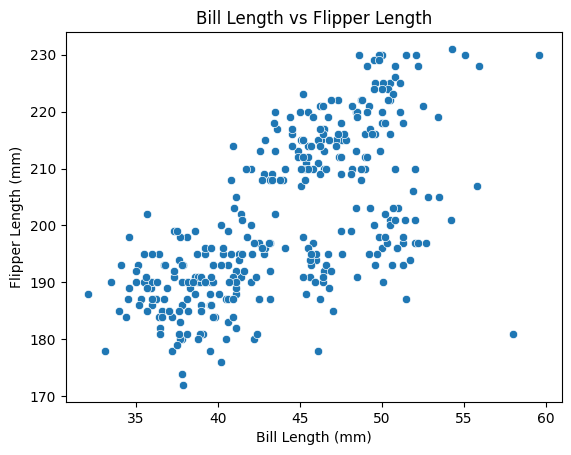

In [14]:
df8 = df.dropna(subset=['bill_length_mm', 'flipper_length_mm'])

sns.scatterplot(data=df8, x='bill_length_mm', y='flipper_length_mm')

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Bill Length vs Flipper Length")
plt.show()

### 2. Enhance the scatter plot from the previous step by using different colors (hue), markers (style), and sizes (size) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

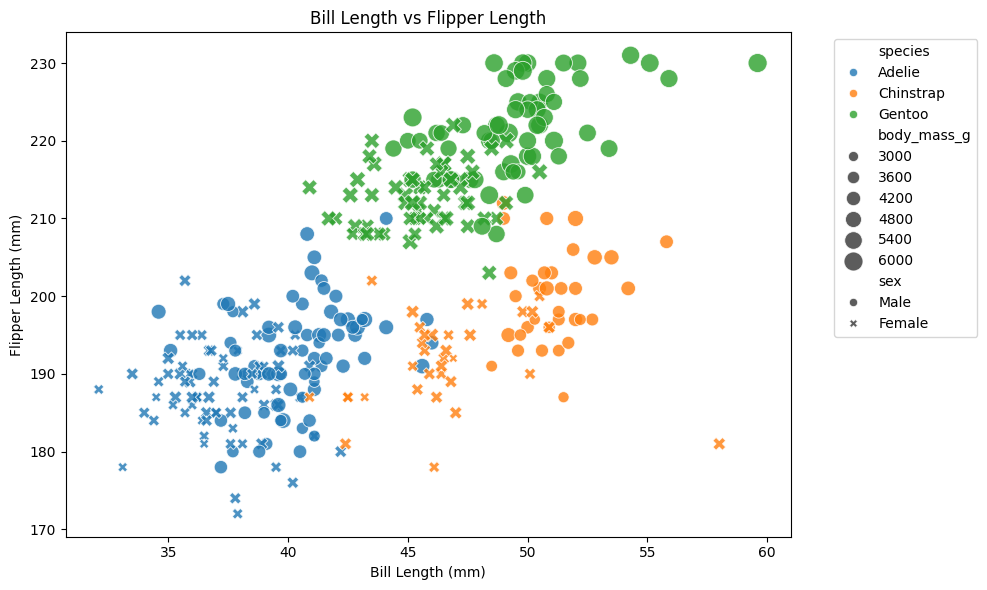

In [15]:
df9 = df.dropna(subset=[
    'bill_length_mm', 'flipper_length_mm', 'species', 'sex', 'body_mass_g'
])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df9,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    style='sex',
    size='body_mass_g',
    sizes=(40, 200),
    alpha=0.8
)

plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.title("Bill Length vs Flipper Length")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()